# WGU Capstone Project: Wyoming Weather Prediction System
This Juypter notebook is used to perform the feature engineering, model training, and evalutation of several techniques for predicting Numerical Weather data.
The data is ingested from an InfluxDB bucket that pulls archived weather data from the OpenMeteo API. The data is stored in a bucket named `OpenMeteo` and is ingested hourly.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from weather_utils import fetch_influx_data, engineer_features, write_influx_data

df_raw = fetch_influx_data()
print(f"Data loaded. Shape: {df_raw.shape}")
print(f"Locations: {df_raw['location'].unique()}")
df_raw.head()

Data loaded. Shape: (26256, 13)
Locations: <StringArray>
['dubois', 'lander', 'pinedale']
Length: 3, dtype: str


,time,location,cloud_cover,cloud_cover_high,cloud_cover_low,cloud_cover_mid,precipitation,rain,relative_humidity,snow_depth,snowfall,temperature,wind_speed
0,2025-03-01 15:00:00+00:00,dubois,0.0,0.0,0.0,0.0,0.0,0.0,60.409607,0.76,0.0,-6.596499,17.334290
1,2025-03-01 16:00:00+00:00,dubois,0.0,0.0,0.0,0.0,0.0,0.0,56.586086,0.76,0.0,-2.546500,15.141414
2,2025-03-01 17:00:00+00:00,dubois,0.0,0.0,0.0,0.0,0.0,0.0,50.156624,0.76,0.0,2.603500,13.151091
3,2025-03-01 18:00:00+00:00,dubois,0.0,0.0,0.0,0.0,0.0,0.0,44.877636,0.76,0.0,5.603500,12.181624
4,2025-03-01 19:00:00+00:00,dubois,0.0,0.0,0.0,0.0,0.0,0.0,39.275940,0.76,0.0,7.153500,11.556504


### Initial Data Investigation and Tests
Identify the date range, shape, and missingness for key fields.

In [3]:
print("Date range:", df_raw["time"].min(), "→", df_raw["time"].max())
print("Rows per location:")
print(df_raw["location"].value_counts())

key_fields = [
    "temperature",
    "precipitation",
    "wind_speed",
    "relative_humidity",
    "cloud_cover",
    "rain",
    "snowfall",
]
available = [col for col in key_fields if col in df_raw.columns]
if available:
    print("\nMissing values by field:")
    print(df_raw[available].isna().mean().sort_values(ascending=False))

Date range: 2025-03-01 15:00:00+00:00 → 2026-03-01 06:00:00+00:00
Rows per location:
location
dubois      8752
lander      8752
pinedale    8752
Name: count, dtype: int64

Missing values by field:
temperature          0.0
precipitation        0.0
wind_speed           0.0
relative_humidity    0.0
cloud_cover          0.0
rain                 0.0
snowfall             0.0
dtype: float64


### Feature Engineering

Prior to training this step will engineer features to capture temporal trends, lagged features, and rolling statistics to aid in model training.
1.  **Temporal Features**: Extract hour, day, month from timestamp.
2.  **Lagged Features**: Use past values (e.g., 1h, 3h, 6h ago) to predict future ones.
3.  **Rolling Statistics**: Moving averages and standard deviations to capture trends.


In [4]:
df_engineered = engineer_features(df_raw)
print(f"Feature Engineering complete. Shape: {df_engineered.shape}")

Feature Engineering complete. Shape: (26184, 106)


### Feature Selection & Correlation
Let's look at how features correlate with our targets. This is merely a snapshot of the features and does not prove causality.

I have also excluded `time` and `location` from the correlation matrix to avoid trivial correlations.


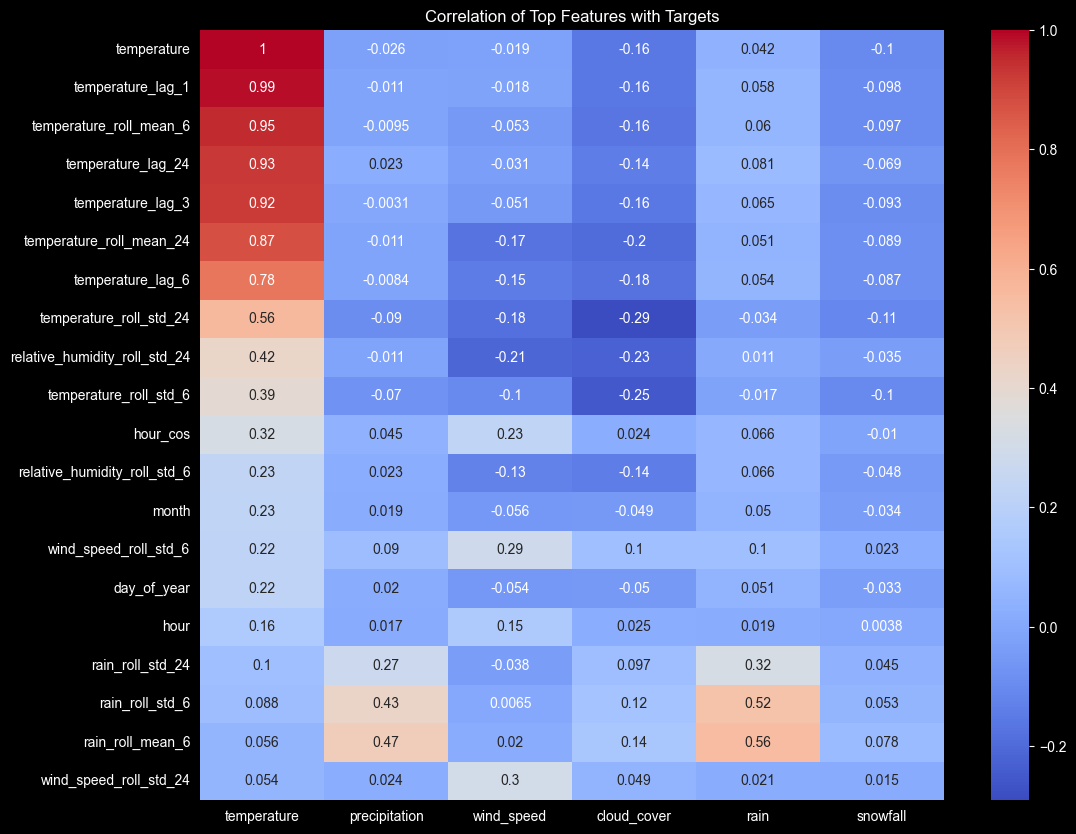

In [5]:
targets = ['temperature', 'precipitation', 'wind_speed', 'cloud_cover', 'rain', 'snowfall']

corr_matrix = df_engineered.drop(columns=['time', 'location']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[targets].sort_values(by=targets, ascending=False).head(20), annot=True, cmap='coolwarm')
plt.title("Correlation of Top Features with Targets")
plt.show()

The correlation matrix calculated as shown above offers insights into what we may come to expect from this type of numerical modeling.
For example, the temperature-lagged features are of high importance and likely are correlated. Though features like Cloud_Cover, and wind_speed will be challenging to infer/predict based on the current set of features.
The higher precipitation values, as shown for rain_roll_std_6 rain_roll_mean_6, may be of use for predicting Precipitation, or rain likelihood, as it will be challenging to predict rain likelihood without including radar data.

### Model Training
Five models will be used for training, and the best performing model will be used for future predictions
- Random forests handle nonlinear relationships and mixed feature types well
- Multi-output regression predicts multiple targets in a single pass
- Gradient Boosting Machines (GBM) are known for their ability to handle complex interactions and are often used for regression tasks
- Ridge regression is a linear regression model that attempts to minimize the L2 norm of the residuals
- XGBoost is a fast, scalable, and effective gradient boosting library that can handle large datasets and complex interactions
- LightGBM is a fast, scalable gradient boosting framework that provides a more efficient and flexible alternative to XGBoost

**Important:** We split **chronologically** (shuffle=False) to avoid future data leaking into the training set.


In [6]:
# 1. Define Features and Targets
drop_cols = ['time', 'location'] + targets
X = df_engineered.drop(columns=drop_cols)
y = df_engineered[targets]

# 2. Encode categorical 'location' if we want to use it as a feature
# We use pd.get_dummies for now, ensuring all expected locations are present
X = pd.concat([X, pd.get_dummies(df_engineered['location'], prefix='loc')], axis=1)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4. Model Definitions
models = {
    "Random Forest": MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    "Linear Regression": MultiOutputRegressor(LinearRegression()),
    "Ridge Regression": MultiOutputRegressor(Ridge(alpha=1.0)),
    "XGBoost": MultiOutputRegressor(XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)),
    "LightGBM": MultiOutputRegressor(LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
}

# 5. Fit Models
for name, model in models.items():
    print(f"Training {name} model...")
    model.fit(X_train, y_train)
    print(f"Training {name} complete.")

Training Random Forest model...
Training Random Forest complete.
Training Linear Regression model...
Training Linear Regression complete.
Training Ridge Regression model...
Training Ridge Regression complete.
Training XGBoost model...
Training XGBoost complete.
Training LightGBM model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002803 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17724
[LightGBM] [Info] Number of data points in the train set: 20947, number of used features: 101
[LightGBM] [Info] Start training from score 7.732888
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003018 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17724
[LightGBM] [Info] Number of data points in

### Model Evaluation
With the models successfully trained, the next step is to evaluate their performance, in this case we can use the Root Mean Squared Error (RMSE) and R² Score for each target.

In [7]:
from collections import namedtuple
import pandas as pd

Score = namedtuple('Score', 'model target rmse r2 stdev')
all_scores = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    for i, target in enumerate(targets):
        rmse = root_mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
        stdev = np.std(y_test.iloc[:, i])
        all_scores.append(Score(name, target, rmse, r2, stdev))

# Create a DataFrame for easier comparison
scores_df = pd.DataFrame(all_scores)

# Display scores
for name in models.keys():
    print(f"\n--- {name} Performance ---")
    model_scores = scores_df[scores_df['model'] == name]
    for _, score in model_scores.iterrows():
        print(f"rmse={score.rmse:.2f}, r2={score.r2:.2f}, stdev={score.stdev:.2f} | {score.target}")

# Summary Comparison for a key target (e.g., Temperature)
print("\n--- Model Comparison (Temperature) ---")
temp_comparison = scores_df[scores_df['target'] == 'temperature'].sort_values('rmse')
print(temp_comparison[['model', 'rmse', 'r2']])


--- Random Forest Performance ---
rmse=0.66, r2=1.00, stdev=9.54 | temperature
rmse=0.23, r2=0.43, stdev=0.30 | precipitation
rmse=2.49, r2=0.88, stdev=7.22 | wind_speed
rmse=1.75, r2=1.00, stdev=42.49 | cloud_cover
rmse=0.18, r2=0.44, stdev=0.24 | rain
rmse=0.08, r2=0.43, stdev=0.10 | snowfall

--- Linear Regression Performance ---
rmse=0.52, r2=1.00, stdev=9.54 | temperature
rmse=0.23, r2=0.38, stdev=0.30 | precipitation
rmse=2.52, r2=0.88, stdev=7.22 | wind_speed
rmse=10.63, r2=0.94, stdev=42.49 | cloud_cover
rmse=0.19, r2=0.37, stdev=0.24 | rain
rmse=0.08, r2=0.39, stdev=0.10 | snowfall

--- Ridge Regression Performance ---
rmse=0.52, r2=1.00, stdev=9.54 | temperature
rmse=0.24, r2=0.36, stdev=0.30 | precipitation
rmse=2.52, r2=0.88, stdev=7.22 | wind_speed
rmse=10.62, r2=0.94, stdev=42.49 | cloud_cover
rmse=0.19, r2=0.37, stdev=0.24 | rain
rmse=0.09, r2=0.32, stdev=0.10 | snowfall

--- XGBoost Performance ---
rmse=0.55, r2=1.00, stdev=9.54 | temperature
rmse=0.22, r2=0.45, stdev=

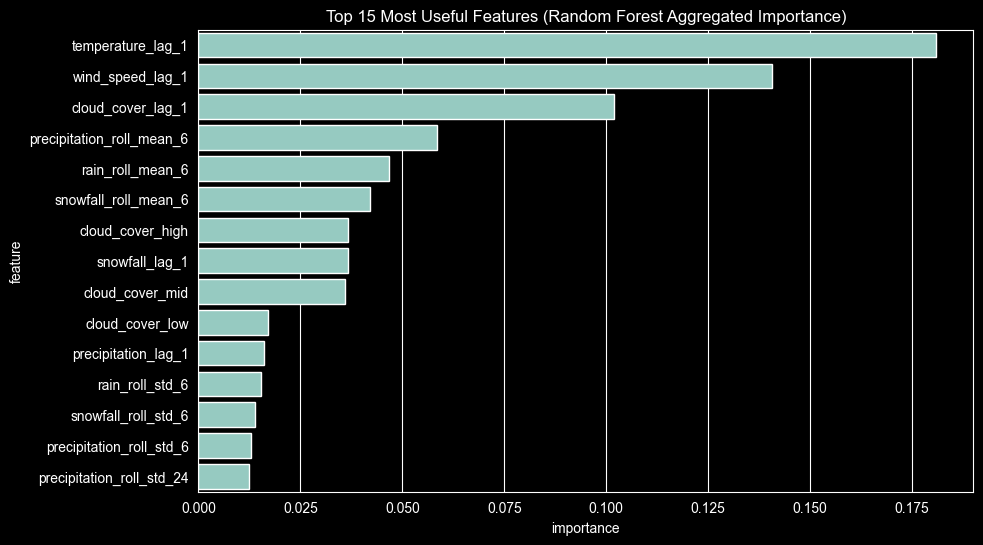

In [9]:
# Feature Importance for the Random Forest Model (Aggregated)
rf_model = models["Random Forest"]
importances = np.mean([est.feature_importances_ for est in rf_model.estimators_], axis=0)
feature_importance_df = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15))
plt.title("Top 15 Most Useful Features (Random Forest Aggregated Importance)")
plt.show()

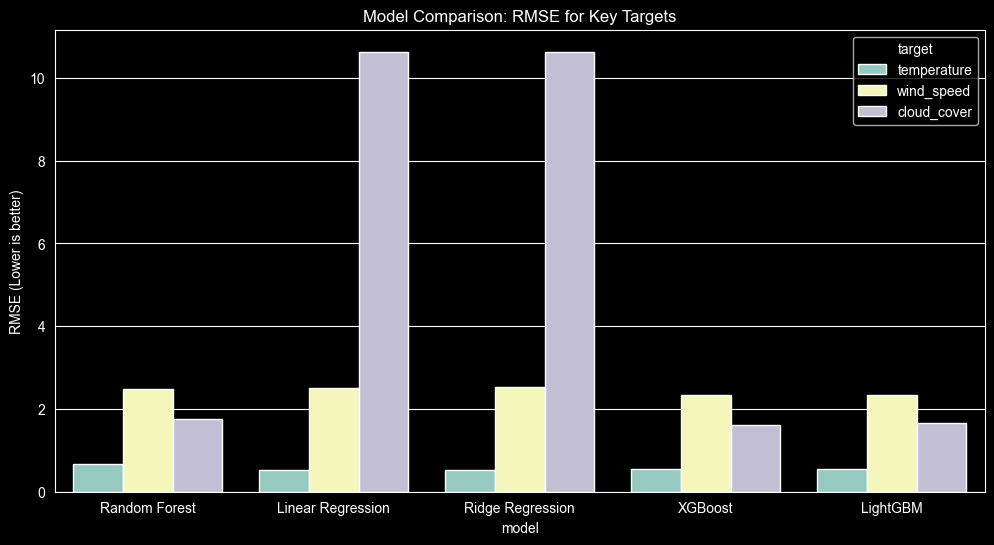

In [10]:
# Model Performance Comparison Plot (RMSE)
plt.figure(figsize=(12, 6))
sns.barplot(x='model', y='rmse', hue='target', data=scores_df[scores_df['target'].isin(['temperature', 'wind_speed', 'cloud_cover'])])
plt.title("Model Comparison: RMSE for Key Targets")
plt.ylabel("RMSE (Lower is better)")
plt.show()

The results shown above represent the model's relative performance across different targets. The RMSE values indicate the average prediction error for each model and target combination. Lower RMSE values suggest better model performance. The plot provides a visual comparison of how well each model predicts temperature, wind speed, and cloud cover, which are key weather variables for our analysis, considering the previous feature important output.

### Generating a 24-hour Nowcast (Future Predictions)
This section shows a **simple recursive forecast** for the next 24 hours using the trained model:

- We start from the **latest available observations** in `df_engineered`.
- For **exogenous variables** we don’t forecast (e.g., `relative_humidity`), we carry the **last observed value** forward.
- For **targets** (`temperature`, `precipitation`, etc.), we **predict one hour ahead**, then feed that prediction back in to build the next hour’s lag/rolling features.

This is a baseline approach for demonstration. For production forecasting, consider using a model that explicitly supports multi-step forecasting or supplying external forecasts for exogenous inputs.


In [11]:
from main import get_global_latest_timestamp

features_to_lag = [
    "temperature",
    "precipitation",
    "wind_speed",
    "relative_humidity",
    "cloud_cover",
    "rain",
    "snowfall",
    "cloud_cover_low",
    "cloud_cover_mid",
    "cloud_cover_high",
]
lags = [1, 3, 6, 24]
windows = [6, 24]


def build_future_features(df_history: pd.DataFrame, model, X_columns, targets, horizon: int = 24) -> pd.DataFrame:
    future_rows = []
    locations = df_history["location"].unique()

    for loc in locations:
        hist = df_history[df_history["location"] == loc].sort_values("time").copy()
        last_time = hist["time"].iloc[-1]

        for step in range(1, horizon + 1):
            future_time = last_time + pd.Timedelta(hours=step)
            row = {"time": future_time, "location": loc}

            # Carrying forward the last observed/predicted values for exogenous variables
            # Variables to carry forward (those that are not targets)
            for col in hist.columns:
                if col not in targets and col not in ["time", "location"] and not col.endswith(("_lag_1", "_lag_3", "_lag_6", "_lag_24", "_roll_mean_6", "_roll_std_6", "_roll_mean_24", "_roll_std_24", "hour", "day_of_year", "month", "hour_sin", "hour_cos")):
                     row[col] = hist[col].iloc[-1]

            # Add placeholders for targets to be predicted
            for target in targets:
                row[target] = np.nan

            # Append the new row to history
            temp_hist = pd.concat([hist, pd.DataFrame([row])], ignore_index=True)

            # Re-engineer features for the entire history or at least the tail
            # Using engineer_features ensures consistency with training
            temp_hist_engineered = engineer_features(temp_hist)

            # Get the last row (our new row) with its engineered features
            latest_row_engineered = temp_hist_engineered.iloc[-1:]

            # Create feature matrix for prediction
            step_X = latest_row_engineered.drop(columns=["time", "location"] + targets, errors="ignore")

            # Add location dummy columns (consistent with training)
            step_X = pd.concat([step_X.reset_index(drop=True), pd.get_dummies(latest_row_engineered['location'], prefix='loc')], axis=1)

            # Ensure column order matches training set and fill missing features with 0
            step_X = step_X.reindex(columns=X_columns, fill_value=0)

            # Predict targets for this hour
            step_pred = model.predict(step_X)[0]
            for idx, target in enumerate(targets):
                row[target] = float(step_pred[idx])

            # Update history with predicted values for recursive forecasting
            hist = pd.concat([hist, pd.DataFrame([row])], ignore_index=True)
            future_rows.append(row)

    # Convert future_rows to a DataFrame
    df_predictions = pd.DataFrame(future_rows)

    # Store predictions in InfluxDB
    store_cols = ["time", "location"] + targets
    df_store = df_predictions[store_cols]
    write_influx_data(df_store, bucket="OpenMeteo", measurement="hourly_weather_predictions")

    return df_predictions


latest_timestamp = get_global_latest_timestamp()
print(f"Latest timestamp in InfluxDB: {latest_timestamp}")

# Use the best performing model for future predictions (e.g., Random Forest or XGBoost)
# For this scaffold, we'll continue with Random Forest
best_model = models["Random Forest"]
future_predictions = build_future_features(df_engineered, best_model, X.columns, targets, horizon=24)
future_predictions.head()

Latest timestamp in InfluxDB: 2026-03-01 06:00:00+00:00
Stored 72 predictions in InfluxDB bucket 'OpenMeteo' under measurement 'hourly_weather_predictions'.


,time,location,cloud_cover_high,cloud_cover_low,cloud_cover_mid,relative_humidity,snow_depth,temperature,precipitation,wind_speed,cloud_cover,rain,snowfall
0,2026-03-01 07:00:00+00:00,dubois,100.0,0.0,80.0,64.184334,0.0,-0.259805,0.0,10.511640,100.0,0.0,0.0
1,2026-03-01 08:00:00+00:00,dubois,100.0,0.0,80.0,64.184334,0.0,-0.441890,0.0,10.693976,100.0,0.0,0.0
2,2026-03-01 09:00:00+00:00,dubois,100.0,0.0,80.0,64.184334,0.0,-0.262715,0.0,10.869306,100.0,0.0,0.0
3,2026-03-01 10:00:00+00:00,dubois,100.0,0.0,80.0,64.184334,0.0,-0.448250,0.0,11.009923,100.0,0.0,0.0
4,2026-03-01 11:00:00+00:00,dubois,100.0,0.0,80.0,64.184334,0.0,-0.171180,0.0,10.963169,100.0,0.0,0.0
